# Homework 5 Building Blocks
This notebook provides code snippets you can use and adapt for your homework. Each section is self-contained and does one thing. You can copy, modify, and combine these blocks as needed.

**Libraries you will need:**

In [29]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm, ListedColormap
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject, Resampling
from shapely.geometry import mapping

import warnings
warnings.filterwarnings('ignore')

---
## Configuration — set your paths here

**This is the only cell you need to edit.** Set `DATA_DIR` to the folder
where your homework data lives. All file paths throughout the notebook
are built from this one variable.


In [30]:
# ============================================================
# SET YOUR DATA DIRECTORY HERE — this is the only path to change
# ============================================================
DATA_DIR = './HW5/Data/Data'

# --- Derived paths (no need to edit these unless you move things around inside the Data folder) ---
nlcd_dir          = os.path.join(DATA_DIR, 'NLCD')
dem_file          = os.path.join(DATA_DIR, 'tucson_dem_mosaic.tif')
watersheds_file   = os.path.join(DATA_DIR, 'Balanced_and_Critical_Watersheds', 'Balanced_and_Critical_Watersheds.shp')
zipcodes_file     = os.path.join(DATA_DIR, 'Zip_Codes',                        'Zip_Codes_(ZIP).shp')
jurisdiction_file = os.path.join(DATA_DIR, 'Jurisdictional_Boundaries',        'Jurisdictional_Boundaries_(JURISBND).shp')

print('DATA_DIR:         ', DATA_DIR)
print('NLCD directory:   ', nlcd_dir)
print('DEM file:         ', dem_file)
print('Watersheds:       ', watersheds_file)
print('Zip Codes:        ', zipcodes_file)
print('Jurisdiction:     ', jurisdiction_file)


DATA_DIR:          ./HW5/Data/Data
NLCD directory:    ./HW5/Data/Data\NLCD
DEM file:          ./HW5/Data/Data\tucson_dem_mosaic.tif
Watersheds:        ./HW5/Data/Data\Balanced_and_Critical_Watersheds\Balanced_and_Critical_Watersheds.shp
Zip Codes:         ./HW5/Data/Data\Zip_Codes\Zip_Codes_(ZIP).shp
Jurisdiction:      ./HW5/Data/Data\Jurisdictional_Boundaries\Jurisdictional_Boundaries_(JURISBND).shp


---
## 1. Read a single landcover raster

Set the directory where your NLCD files live and the year you want to load. The file name is assembled from those two variables. We open the file with `rasterio`, read the first band into a numpy array, and print some basic metadata so we know it loaded correctly.

In [ ]:
# --- Set the year you want to load ---
year     = 2019

# Assemble the file path from the directory and year
lc_file = os.path.join(nlcd_dir, f'Annual_NLCD_LndCov_{year}_CU_C1V1_e88ec285-1ee1-44ad-9f9c-7bef52ff0f40.tiff')

# Open the raster and read it into a numpy array
with rasterio.open(lc_file) as src:
    lc_data      = src.read(1)       # read band 1
    print(lc_data.shape)              # print the shape of the array (rows, cols)
    
    
# Note you can also learn about the raster properties (metadata) by opening it with rasterio and accessing its attributes. This is useful for understanding the data and for troubleshooting if you run into issues later on.
with rasterio.open(lc_file) as src:    
    lc_nodata    = src.nodata        # nodata value (pixels outside the study area)
    lc_crs       = src.crs          # coordinate reference system
    lc_transform = src.transform    # affine transform (maps pixel -> coordinates)
    lc_bounds    = src.bounds       # bounding box

print('File loaded:', lc_file)
print('Array shape (rows, cols):', lc_data.shape)
print('Data type:', lc_data.dtype)
print('CRS:', lc_crs)
print('Nodata value:', lc_nodata)
print('Bounding box:', lc_bounds)
print('Unique NLCD class values present:', np.unique(lc_data))

---
## 2. Read all landcover rasters for a range of years

Set a start year and end year and we loop over every year in that range, build the file path, and store each array in a dictionary keyed by year. This gives you all years in memory at once so you can easily compare or plot any of them.

In [32]:
# --- Set the year range ---
year_start = 1985
year_end   = 2024

# Output directory for per-year NLCD arrays
arrays_dir = os.path.join(DATA_DIR, 'NLCD_arrays')
os.makedirs(arrays_dir, exist_ok=True)

lc_by_year = {}
for year in range(year_start, year_end + 1):
    lc_file = os.path.join(nlcd_dir, f'Annual_NLCD_LndCov_{year}_CU_C1V1_e88ec285-1ee1-44ad-9f9c-7bef52ff0f40.tiff')
    if not os.path.exists(lc_file):
        print(f'SKIP {year}: file not found: {lc_file}')
        continue

    with rasterio.open(lc_file) as src:
        lc_data_year = src.read(1)

    lc_by_year[year] = lc_data_year

    save_path = os.path.join(arrays_dir, f'NLCD_{year}.npy')
    np.save(save_path, lc_data_year)

    print(f'Loaded {year}: shape={lc_data_year.shape}, dtype={lc_data_year.dtype}, saved to {save_path}')

print(f'Finished loading {len(lc_by_year)} years ({year_start}-{year_end}).')



Loaded 1985: shape=(3891, 3872), dtype=uint8, saved to ./HW5/Data/Data\NLCD_arrays\NLCD_1985.npy
Loaded 1986: shape=(3891, 3872), dtype=uint8, saved to ./HW5/Data/Data\NLCD_arrays\NLCD_1986.npy
Loaded 1987: shape=(3891, 3872), dtype=uint8, saved to ./HW5/Data/Data\NLCD_arrays\NLCD_1987.npy
Loaded 1988: shape=(3891, 3872), dtype=uint8, saved to ./HW5/Data/Data\NLCD_arrays\NLCD_1988.npy
Loaded 1989: shape=(3891, 3872), dtype=uint8, saved to ./HW5/Data/Data\NLCD_arrays\NLCD_1989.npy
Loaded 1990: shape=(3891, 3872), dtype=uint8, saved to ./HW5/Data/Data\NLCD_arrays\NLCD_1990.npy
Loaded 1991: shape=(3891, 3872), dtype=uint8, saved to ./HW5/Data/Data\NLCD_arrays\NLCD_1991.npy
Loaded 1992: shape=(3891, 3872), dtype=uint8, saved to ./HW5/Data/Data\NLCD_arrays\NLCD_1992.npy
Loaded 1993: shape=(3891, 3872), dtype=uint8, saved to ./HW5/Data/Data\NLCD_arrays\NLCD_1993.npy
Loaded 1994: shape=(3891, 3872), dtype=uint8, saved to ./HW5/Data/Data\NLCD_arrays\NLCD_1994.npy
Loaded 1995: shape=(3891, 3872

---
## 3. Read the DEM

We read the digital elevation model the same way we read the landcover raster. The DEM stores elevation in metres as a continuous floating-point value rather than discrete class codes.

In [33]:
with rasterio.open(dem_file) as src:
    dem_data      = src.read(1).astype(float)
    dem_nodata    = src.nodata
    dem_crs       = src.crs
    dem_transform = src.transform
    dem_bounds    = src.bounds
    dem_res_m     = abs(src.transform.a)   # pixel width in metres

# Replace nodata values with NaN so they are ignored in calculations
if dem_nodata is not None:
    dem_data[dem_data == dem_nodata] = np.nan

print('DEM file loaded:', dem_file)
print('Array shape:', dem_data.shape)
print('CRS:', dem_crs)
print('Pixel resolution:', dem_res_m, 'm')
print('Elevation range: %.0f m - %.0f m' % (np.nanmin(dem_data), np.nanmax(dem_data)))

DEM file loaded: ./HW5/Data/Data\tucson_dem_mosaic.tif
Array shape: (3613, 7212)
CRS: EPSG:4269
Pixel resolution: 0.000277777777786999 m
Elevation range: 161 m - 2793 m


---
## 4. Read shapefiles

We read each vector dataset using `geopandas`. Provide the directory and the filename (including the `.shp` extension) for each layer. `geopandas` automatically reads the associated `.dbf`, `.prj`, and `.shx` files as long as they are in the same folder.

In [34]:
# Read each shapefile into a GeoDataFrame
watersheds = gpd.read_file(watersheds_file, engine='pyogrio')
zipcodes   = gpd.read_file(zipcodes_file,   engine='pyogrio')
jurisdiction = gpd.read_file(jurisdiction_file, engine='pyogrio')

# Quick check: print the CRS and first few rows of each
print('--- Watersheds ---')
print('CRS:', watersheds.crs)
print('Columns:', list(watersheds.columns))
print(watersheds.head(3), '\n')

print('--- Zip Codes ---')
print('CRS:', zipcodes.crs)
print('Columns:', list(zipcodes.columns))
print(zipcodes.head(3), '\n')

print('--- Jurisdictional Boundaries ---')
print('CRS:', jurisdiction.crs)
print('Columns:', list(jurisdiction.columns))
print(jurisdiction.head(3))

--- Watersheds ---
CRS: EPSG:2868
Columns: ['ID', 'WATERSHED', 'STATUS', 'URL', 'DATASOURCE', 'GlobalID', 'OBJECTID', 'vectorsdeG', 'ShapeSTAre', 'ShapeSTLen', 'geometry']
   ID              WATERSHED    STATUS   URL DATASOURCE  \
0   0           Kreuger Wash  critical  None    BALCRIT   
1   0         Ruthrauff Wash  critical  None    BALCRIT   
2   0  Christopher City Wash  balanced  None    BALCRIT   

                                 GlobalID  OBJECTID  vectorsdeG    ShapeSTAre  \
0  {6379DB96-A6C0-47DB-9620-3EF2F8BA40AE}         1    10630918  1.113190e+07   
1  {511770AF-22C2-4D18-BB5E-819332843A44}         2    79348918  7.907498e+07   
2  {010372FB-DEDE-4D77-9577-43DCFCAC4B79}         3     6260600  6.328645e+06   

     ShapeSTLen                                           geometry  
0  20927.487021  POLYGON ((983073.272 458640.441, 983051.226 45...  
1  69755.711218  POLYGON ((983435.12 468153.116, 983482.163 468...  
2  13544.336517  POLYGON ((1014268.968 461917.704, 1014452.

---
## 5. Check that projections match

Before overlaying rasters and vectors (or two rasters), their coordinate reference systems (CRS) must match — otherwise your layers will not line up. Here we compare the landcover raster CRS against the DEM and each vector layer, and reproject any that differ.

In [35]:
# Print the CRS of every dataset so we can compare them
print('Landcover CRS:   ', lc_crs)
print('DEM CRS:         ', dem_crs)
print('Watersheds CRS:  ', watersheds.crs)
print('Zip Codes CRS:   ', zipcodes.crs)
print('Jurisdiction CRS:', jurisdiction.crs)

# Check whether each dataset matches the landcover raster CRS
print('\nDo projections match the landcover raster?')
print('  DEM:          ', dem_crs == lc_crs)
print('  Watersheds:   ', watersheds.crs == lc_crs)
print('  Zip Codes:    ', zipcodes.crs == lc_crs)
print('  Jurisdiction: ', jurisdiction.crs == lc_crs)

# If the vector layers don't match, reproject them to the raster CRS.
# It is usually easier to reproject vectors than rasters.
# The lines below reproject all three vector layers to match the landcover raster.
watersheds   = watersheds.to_crs(lc_crs)
zipcodes     = zipcodes.to_crs(lc_crs)
jurisdiction = jurisdiction.to_crs(lc_crs)

# Note: if the DEM CRS doesn't match the landcover CRS, you will need to
# reproject one of the rasters — see Block 9 for how to do this.

print('\nAfter reprojection:')
print('  Watersheds match raster:   ', watersheds.crs == lc_crs)
print('  Zip Codes match raster:    ', zipcodes.crs == lc_crs)
print('  Jurisdiction match raster: ', jurisdiction.crs == lc_crs)

Landcover CRS:    PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
DEM CRS:          EPSG:4269
Watersheds CRS:   EPSG:2868
Zip Codes CRS:    EPSG:3857
Jurisdiction CRS: EPSG:3857

Do projections match the landcover raster?
  DEM:           False
  Watersheds:    False
  Zip Codes:     False
  Jurisdiction:  False

After reprojection:
  Watersheds match raster:    True
  Zip Codes match raster:     True
  Jurisdiction match raster:  True


---
## 6. Map one year of landcover with shapefiles overlaid

We build a discrete colormap from the official NLCD colors, display the raster, then overlay the vector boundaries. The map extent is clipped to the bounding box of the landcover raster so we don't see empty space around the edges.

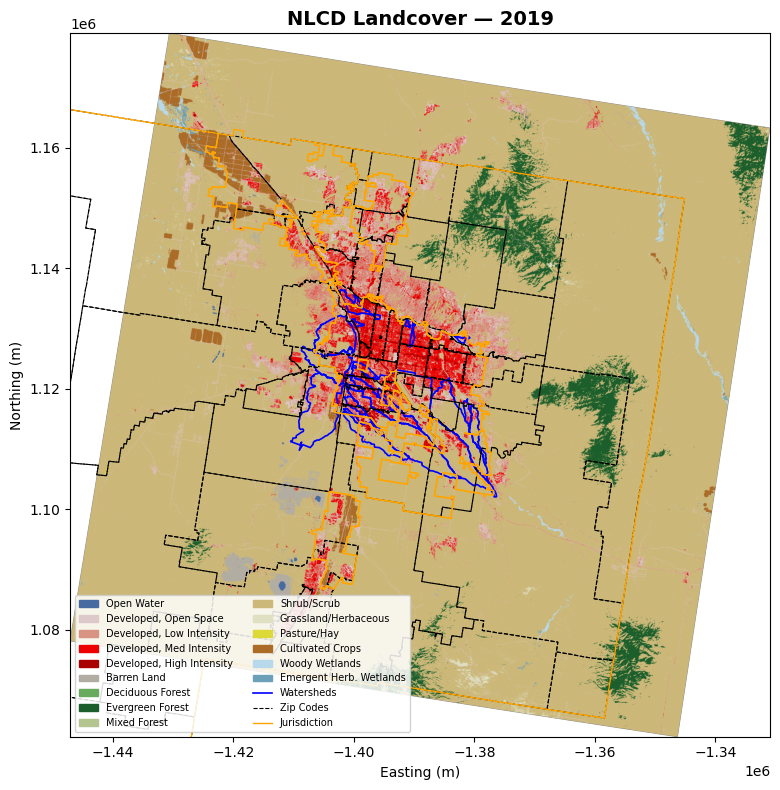

In [36]:
#ability to choose a new year for this step
year = 2019

# Official NLCD class codes, labels, and hex colors
# Reference: https://www.mrlc.gov/data/type/land-cover
NLCD_CLASSES = {
    11: ('Open Water',                '#476BA0'),
    12: ('Perennial Ice/Snow',        '#D1DDF9'),
    21: ('Developed, Open Space',     '#DDC9C9'),
    22: ('Developed, Low Intensity',  '#D89382'),
    23: ('Developed, Med Intensity',  '#ED0000'),
    24: ('Developed, High Intensity', '#AA0000'),
    31: ('Barren Land',               '#B2ADA3'),
    41: ('Deciduous Forest',          '#68AB5F'),
    42: ('Evergreen Forest',          '#1C5F2C'),
    43: ('Mixed Forest',              '#B5C58F'),
    51: ('Dwarf Scrub',               '#AF963C'),
    52: ('Shrub/Scrub',               '#CCB879'),
    71: ('Grassland/Herbaceous',      '#DFDFC2'),
    72: ('Sedge/Herbaceous',          '#D1D182'),
    73: ('Lichens',                   '#A3CC51'),
    74: ('Moss',                      '#82BA9E'),
    81: ('Pasture/Hay',               '#DCD939'),
    82: ('Cultivated Crops',          '#AB6C28'),
    90: ('Woody Wetlands',            '#B8D9EB'),
    95: ('Emergent Herb. Wetlands',   '#6C9FB8')
}

# Find which NLCD classes are actually present in this year's data
nodata_val = int(lc_nodata) if lc_nodata is not None else 0
present_classes = sorted(set(np.unique(lc_data)) - {nodata_val})

# Build a colormap and normalizer from only the classes that appear
colors = [NLCD_CLASSES.get(c, ('Unknown', '#888888'))[1] for c in present_classes]
cmap   = ListedColormap(colors)
bounds = [c - 0.5 for c in present_classes] + [present_classes[-1] + 0.5]
norm   = BoundaryNorm(bounds, cmap.N)

# Mask nodata pixels so they show as transparent
lc_display = lc_data.astype(float)
lc_display[lc_data == nodata_val] = np.nan


# The extent tells matplotlib the coordinate range of the raster
extent = [lc_bounds.left, lc_bounds.right, lc_bounds.bottom, lc_bounds.top]

fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(lc_display, cmap=cmap, norm=norm, extent=extent, origin='upper')

# Overlay vector boundaries
watersheds.boundary.plot(  ax=ax, edgecolor='blue',   linewidth=1.2, label='Watersheds')
zipcodes.boundary.plot(    ax=ax, edgecolor='black',  linewidth=0.8, linestyle='--', label='Zip Codes')
jurisdiction.boundary.plot(ax=ax, edgecolor='orange', linewidth=1.0, label='Jurisdiction')

# Clip the map extent to the raster bounding box
ax.set_xlim(lc_bounds.left,   lc_bounds.right)
ax.set_ylim(lc_bounds.bottom, lc_bounds.top)

# Build a legend from the classes present in the data
lc_patches = []
for c in present_classes:
    lc_patches.append(
        mpatches.Patch(
            color=NLCD_CLASSES.get(c, ('?','#888'))[1],
            label=NLCD_CLASSES.get(c, ('?','#888'))[0]
        )
    )
boundary_lines = [
    Line2D([0],[0], color='blue',   lw=1.2,       label='Watersheds'),
    Line2D([0],[0], color='black',  lw=0.8, ls='--', label='Zip Codes'),
    Line2D([0],[0], color='orange', lw=1.0,       label='Jurisdiction'),
]
ax.legend(handles=lc_patches + boundary_lines,
          loc='lower left', fontsize=7, framealpha=0.85, ncol=2)

ax.set_title(f'NLCD Landcover — {year}', fontsize=14, fontweight='bold')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

---
## 7a. Count pixels of a single landcover type

NLCD class codes are integers. To count how many pixels belong to a particular class, we create a boolean mask (True where the array equals that code) and sum it up. Each True counts as 1.

In [37]:
# --- Set the NLCD class code you want to count ---
# e.g. 52 = Shrub/Scrub, 21 = Developed Open Space, 31 = Barren Land
target_class = 52
target_label = NLCD_CLASSES.get(target_class, ('Unknown class', ''))[0]

# Count pixels equal to that class code
pixel_count = np.sum(lc_data == target_class)

print(f'NLCD class {target_class} ({target_label})')
print(f'  Pixel count: {pixel_count:,}')

NLCD class 52 (Shrub/Scrub)
  Pixel count: 9,614,911


---
## 7b. Count pixels of every landcover type for one year

We loop over every NLCD class present in the data and print the pixel count for each. This gives a complete breakdown of landcover composition for the single year loaded in Block 1.

In [49]:
## YOUR CODE HERE: Loop through all the classes present in the data, count the pixels for each class, and print the class code, label, and pixel count.  

# Loop through each NLCD class present in the data
for class_code in present_classes:
    # Count pixels equal to this class code
    pixel_count = np.sum(lc_data == class_code)
    
    # Get the label from NLCD_CLASSES dictionary
    label = NLCD_CLASSES.get(class_code, ('Unknown class', ''))[0]
    
    # Print the class code, label, and pixel count
    print(f'Class {class_code}: {label} - {pixel_count:,} pixels')

Class 11: Open Water - 4,890 pixels
Class 21: Developed, Open Space - 285,482 pixels
Class 22: Developed, Low Intensity - 506,462 pixels
Class 23: Developed, Med Intensity - 322,765 pixels
Class 24: Developed, High Intensity - 43,002 pixels
Class 31: Barren Land - 63,857 pixels
Class 41: Deciduous Forest - 549 pixels
Class 42: Evergreen Forest - 451,154 pixels
Class 43: Mixed Forest - 97 pixels
Class 52: Shrub/Scrub - 9,614,911 pixels
Class 71: Grassland/Herbaceous - 25,217 pixels
Class 81: Pasture/Hay - 2,959 pixels
Class 82: Cultivated Crops - 156,714 pixels
Class 90: Woody Wetlands - 37,579 pixels
Class 95: Emergent Herb. Wetlands - 10,637 pixels


---
## 7c. Count pixels of every landcover type for every year

We loop over all years loaded in Block 2 (`lc_all_years`) and for each year count pixels per NLCD class. Results are stored in a tidy DataFrame with one row per year-class combination, which makes it easy to filter, group, or plot over time.

In [50]:
## Your code here: Loop through the years, load each raster into an array, and store it in a dictionary. Print the shape of each array as you load it to confirm they are all the same size. At the end, print the total number of years loaded.

#Hint: you can first initilize an empty list like this rows = [] and then append a dictionary for each class in each year like this rows.append({'year': yr, 'nlcd_code': int(code), 'label': label, 'pixels': count})

# Initialize list to store results
rows = []

# Loop through each year
for year in range(year_start, year_end + 1):
    # Load the raster for this year
    if 'lc_by_year' in globals() and year in lc_by_year:
        lc_year = lc_by_year[year]
    else:
        year_file = os.path.join(arrays_dir, f'NLCD_{year}.npy')
        if not os.path.exists(year_file):
            print(f'SKIP {year}: no raster data found')
            continue
        lc_year = np.load(year_file)
    
    # Get unique classes in this year's data (excluding nodata if present)
    nodata_val = int(lc_nodata) if lc_nodata is not None else 0
    classes_in_year = sorted(set(np.unique(lc_year)) - {nodata_val})
    
    # For each class, count pixels and record
    for code in classes_in_year:
        pixel_count = np.sum(lc_year == code)
        label = NLCD_CLASSES.get(int(code), ('Unknown class', ''))[0]
        rows.append({'year': year, 'nlcd_code': int(code), 'label': label, 'pixels': int(pixel_count)})
    
    print(f'Processed year {year}: {len(classes_in_year)} classes')

# Create DataFrame from results
df_pixel_counts = pd.DataFrame(rows)

# Save to CSV for searching and referencing
output_csv = os.path.join(DATA_DIR, 'nlcd_pixel_counts_by_year.csv')
df_pixel_counts.to_csv(output_csv, index=False)

print(f'Saved pixel counts to {output_csv}')
print(f'Total records: {len(df_pixel_counts)}')
print('Sample of results:')
print(df_pixel_counts.head(10))




Processed year 1985: 15 classes
Processed year 1986: 15 classes
Processed year 1987: 15 classes
Processed year 1988: 15 classes
Processed year 1989: 15 classes
Processed year 1990: 15 classes
Processed year 1991: 15 classes
Processed year 1992: 15 classes
Processed year 1993: 15 classes
Processed year 1994: 15 classes
Processed year 1995: 15 classes
Processed year 1996: 15 classes
Processed year 1997: 15 classes
Processed year 1998: 15 classes
Processed year 1999: 15 classes
Processed year 2000: 15 classes
Processed year 2001: 15 classes
Processed year 2002: 15 classes
Processed year 2003: 15 classes
Processed year 2004: 15 classes
Processed year 2005: 15 classes
Processed year 2006: 15 classes
Processed year 2007: 15 classes
Processed year 2008: 15 classes
Processed year 2009: 15 classes
Processed year 2010: 15 classes
Processed year 2011: 15 classes
Processed year 2012: 15 classes
Processed year 2013: 15 classes
Processed year 2014: 15 classes
Processed year 2015: 15 classes
Processe

---
## 8. Reclassify the DEM into two elevation bands

Before choosing a threshold, we plot a histogram to see how elevation values
are distributed across the study area — this helps us pick a meaningful break point.

We then use `np.digitize()` to classify every pixel into a bin, which is the
standard approach for raster reclassification. `np.digitize` assigns each pixel
a bin number based on where its value falls relative to the defined breaks:
- Values **below** the first break → bin `0` (we will mask these out as nodata)
- Values in the **first** bin → bin `1` (Low elevation)
- Values in the **second** bin → bin `2` (High elevation)

We use `-np.inf` and `np.inf` as the outer bounds to catch all values.
After classifying, we mask out any pixels that were originally `NaN` (nodata),
since `np.digitize` assigns those a spurious bin number.


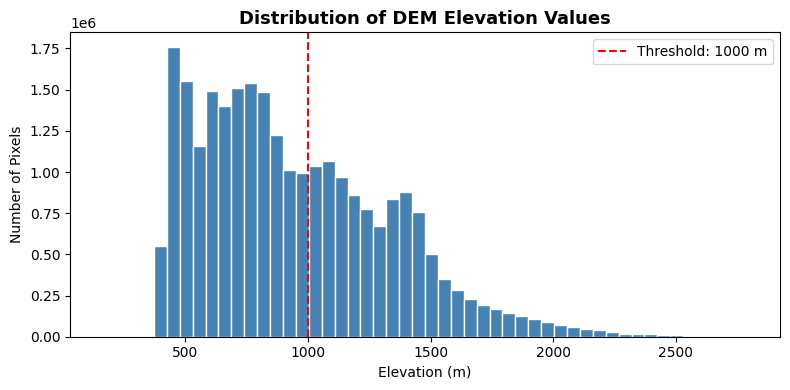

Unique values after np.digitize (before masking): [1 2 3]

Elevation threshold: 1000 m
  Low  elevation (<  1000 m): 15,607,080 pixels
  High elevation (>= 1000 m): 10,442,664 pixels


In [40]:
# ── Step 1: Plot a histogram to explore the elevation distribution
# This helps us pick a meaningful threshold before classifying
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dem_data[~np.isnan(dem_data)].ravel(), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of DEM Elevation Values', fontsize=13, fontweight='bold')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Number of Pixels')

# Mark the proposed threshold on the histogram
threshold_m = 1000
ax.axvline(x=threshold_m, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold: {threshold_m} m')
ax.legend()
plt.tight_layout()
plt.show()

# ── Step 2: Define class bins and classify with np.digitize
# Class 1: below threshold  (Low elevation)
# Class 2: above threshold  (High elevation)
# We use -np.inf and np.inf as outer bounds to capture all valid values
class_bins = [-np.inf, threshold_m, np.inf]

# np.digitize assigns each pixel a bin number based on class_bins
# NaN pixels get assigned bin 0 — we will mask those out next
elev_class = np.digitize(dem_data, class_bins)

print('Unique values after np.digitize (before masking):', np.unique(elev_class))

# ── Step 3: Mask out pixels that were originally NaN (nodata)
# np.digitize cannot handle NaN — it assigns them bin 3 (one beyond our highest class)
# We set those back to NaN using np.where
elev_class = np.where(np.isnan(dem_data), np.nan, elev_class).astype(float)

# Count pixels in each bin
n_low  = int(np.sum(elev_class == 1))
n_high = int(np.sum(elev_class == 2))

print(f'\nElevation threshold: {threshold_m} m')
print(f'  Low  elevation (<  {threshold_m} m): {n_low:>10,} pixels')
print(f'  High elevation (>= {threshold_m} m): {n_high:>10,} pixels')


---
## 9. Reproject the landcover raster to match the DEM grid

Before we can compare landcover and elevation pixel-by-pixel, both arrays must be on the exact same grid (same CRS, same cell size, same origin). We use `rasterio.warp.reproject` to warp the landcover array onto the DEM grid. We print the shape before and after to confirm the alignment.

In [41]:
print('Before reprojection:')
print('  Landcover shape:', lc_data.shape)
print('  DEM shape:      ', dem_data.shape)
print('  Landcover CRS:  ', lc_crs)
print('  DEM CRS:        ', dem_crs)

# Create an empty array with the same shape as the DEM to hold the reprojected landcover
lc_reproj = np.empty((dem_data.shape[0], dem_data.shape[1]), dtype=np.float32)

# Reproject: warp lc_data from its own grid onto the DEM grid.
# Nearest-neighbor resampling preserves discrete class codes.
with rasterio.open(lc_file) as src:
    reproject(
        source        = rasterio.band(src, 1),
        destination   = lc_reproj,
        dst_transform = dem_transform,
        dst_crs       = dem_crs,
        resampling    = Resampling.nearest,
    )

print('\nAfter reprojection:')
print('  Reprojected landcover shape:', lc_reproj.shape)
print('  DEM shape:                  ', dem_data.shape)
print('  Shapes match:', lc_reproj.shape == dem_data.shape)

Before reprojection:
  Landcover shape: (3891, 3872)
  DEM shape:       (3613, 7212)
  Landcover CRS:   PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  DEM CRS:         EPSG:4269

After reprojection:
  Reprojected landcover shape: (3613, 7212)
  DEM shape:                   (3613, 7212)
  Shapes match: True


---
## 10. Count pixels of each landcover type in the low elevation band

Now that the landcover and elevation classification are on the same grid, we can use numpy boolean indexing to extract only the landcover pixels that fall within the low elevation band, then count how many pixels belong to each NLCD class.

In [42]:
# Create a boolean mask that is True only where elevation class == 1 (Low)
low_elev_mask = (elev_class == 1)

# Use that mask to extract the landcover values in the low elevation band
lc_in_low = lc_reproj[low_elev_mask].astype(int)

# Get the unique class codes and their pixel counts
class_codes, class_counts = np.unique(lc_in_low, return_counts=True)

print('Landcover pixel counts in the LOW elevation band:')
print(f'{"Code":<6} {"Label":<30} {"Pixels":>12}')
print('-' * 50)
for code, count in zip(class_codes, class_counts):
    if int(code) == int(lc_nodata):   # skip nodata pixels
        continue
    label = NLCD_CLASSES.get(int(code), ('Unknown class', ''))[0]
    print(f'{int(code):<6} {label:<30} {count:>12,}')

Landcover pixel counts in the LOW elevation band:
Code   Label                                Pixels
--------------------------------------------------
11     Open Water                            1,963
21     Developed, Open Space               279,348
22     Developed, Low Intensity            502,529
23     Developed, Med Intensity            342,157
24     Developed, High Intensity            48,597
31     Barren Land                           9,677
41     Deciduous Forest                        430
42     Evergreen Forest                        222
43     Mixed Forest                            104
52     Shrub/Scrub                       3,761,566
71     Grassland/Herbaceous                  8,938
81     Pasture/Hay                           1,023
82     Cultivated Crops                    128,667
90     Woody Wetlands                       35,333
95     Emergent Herb. Wetlands               8,986


---
## 11. Do the same thing with a for loop across both elevation bands

Instead of repeating the code twice, we loop over both elevation bands. The structure is the same as above — mask, extract, count — but driven by a `for` loop.

In [43]:
# Dictionary mapping band id to a human-readable label
elevation_bands = {
    1: 'Low  (< 1000 m)',
    2: 'High (>= 1000 m)',
}

for band_id, band_label in elevation_bands.items():

    # Mask for this band
    band_mask = (elev_class == band_id)

    # Extract landcover pixels within this band
    lc_in_band = lc_reproj[band_mask].astype(int)

    # Count pixels per class
    class_codes, class_counts = np.unique(lc_in_band, return_counts=True)

    print(f'\n=== Elevation band: {band_label} ===')
    print(f'{"Code":<6} {"Label":<30} {"Pixels":>12}')
    print('-' * 50)
    for code, count in zip(class_codes, class_counts):
        if int(code) == int(lc_nodata):   # skip nodata pixels
            continue
        label = NLCD_CLASSES.get(int(code), ('Unknown class', ''))[0]
        print(f'{int(code):<6} {label:<30} {count:>12,}')


=== Elevation band: Low  (< 1000 m) ===
Code   Label                                Pixels
--------------------------------------------------
11     Open Water                            1,963
21     Developed, Open Space               279,348
22     Developed, Low Intensity            502,529
23     Developed, Med Intensity            342,157
24     Developed, High Intensity            48,597
31     Barren Land                           9,677
41     Deciduous Forest                        430
42     Evergreen Forest                        222
43     Mixed Forest                            104
52     Shrub/Scrub                       3,761,566
71     Grassland/Herbaceous                  8,938
81     Pasture/Hay                           1,023
82     Cultivated Crops                    128,667
90     Woody Wetlands                       35,333
95     Emergent Herb. Wetlands               8,986

=== Elevation band: High (>= 1000 m) ===
Code   Label                                Pixels

---
## 12. Summarize area (km²) in each elevation band by landcover type

Pixel counts are useful but area is more meaningful for comparison. We convert pixel counts to km² using the DEM pixel size, and collect the results into a pandas DataFrame for easy reading.

In [44]:
# Area of one pixel in m²  (pixel is square, side = dem_res_m metres)
pixel_area_m2 = dem_res_m ** 2

for band_id, band_label in elevation_bands.items():

    band_mask  = (elev_class == band_id)
    lc_in_band = lc_reproj[band_mask].astype(int)

    class_codes, class_counts = np.unique(lc_in_band, return_counts=True)

    # Build a list of rows, then make a DataFrame
    rows = []
    for code, count in zip(class_codes, class_counts):
        if int(code) == int(lc_nodata):   # skip nodata pixels
            continue
        label    = NLCD_CLASSES.get(int(code), ('Unknown class', ''))[0]
        area_m2 = count * pixel_area_m2
        rows.append({'nlcd_code': int(code), 'label': label,
                     'pixels': count, 'area_m2': round(area_m2, 2)})

    df = pd.DataFrame(rows).sort_values('area_m2', ascending=False)

    print(f'\n=== Elevation band: {band_label} ===')
    print(df.to_string(index=False))



=== Elevation band: Low  (< 1000 m) ===
 nlcd_code                     label  pixels  area_m2
        52               Shrub/Scrub 3761566     0.29
        22  Developed, Low Intensity  502529     0.04
        23  Developed, Med Intensity  342157     0.03
        21     Developed, Open Space  279348     0.02
        82          Cultivated Crops  128667     0.01
        11                Open Water    1963     0.00
        24 Developed, High Intensity   48597     0.00
        41          Deciduous Forest     430     0.00
        31               Barren Land    9677     0.00
        43              Mixed Forest     104     0.00
        42          Evergreen Forest     222     0.00
        71      Grassland/Herbaceous    8938     0.00
        81               Pasture/Hay    1023     0.00
        90            Woody Wetlands   35333     0.00
        95   Emergent Herb. Wetlands    8986     0.00

=== Elevation band: High (>= 1000 m) ===
 nlcd_code                     label  pixels  area_m2

---
## 13. Clip the landcover raster to the full extent of the zip code shapefile

`rasterio.mask.mask` clips a raster to the union of all features in a vector layer. We pass all zip code polygons at once, and the result is a new array cropped to their combined bounding extent.

Original landcover shape: (3891, 3872)
Clipped to all zip codes: (3891, 3398)


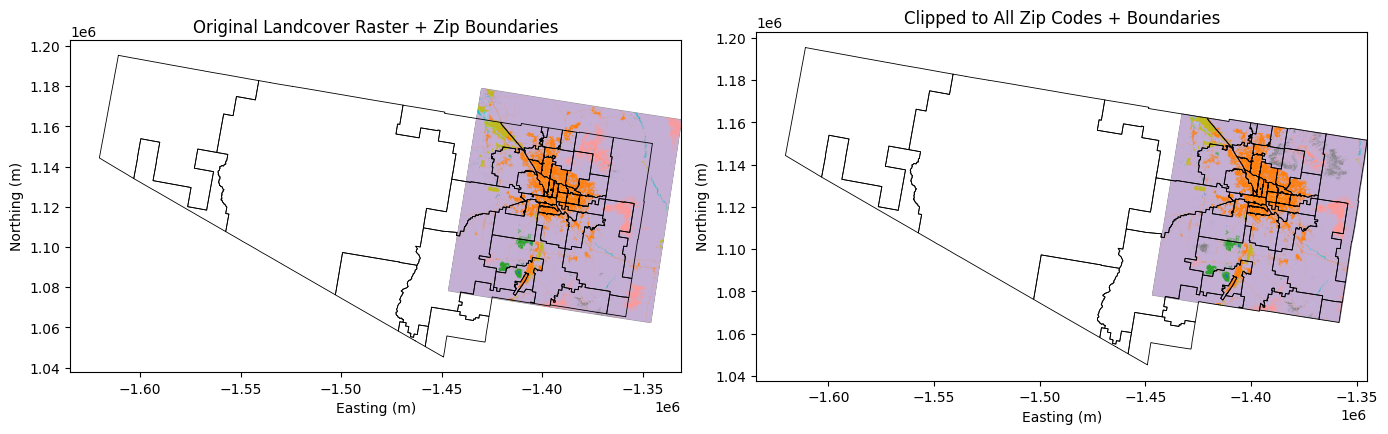

In [45]:
# Make sure the zip codes are in the same CRS as the landcover raster
zipcodes_reproj = zipcodes.to_crs(lc_crs)

# Convert all geometries to the GeoJSON-style dict that rasterio expects
all_zip_shapes = [mapping(geom) for geom in zipcodes_reproj.geometry]

# Clip the raster — crop=True trims the output to the tightest bounding box
with rasterio.open(lc_file) as src:
    lc_clipped_all, clip_transform_all = rio_mask(src, all_zip_shapes, crop=True)

# rio_mask returns shape (bands, rows, cols) — take band 0
lc_clipped_all = lc_clipped_all[0]

print('Original landcover shape:', lc_data.shape)
print('Clipped to all zip codes:', lc_clipped_all.shape)

# --- Plot pre- and post-clipped rasters ---
nodata_plot = int(lc_nodata) if lc_nodata is not None else 0

orig_display = lc_data.astype(float)
orig_display[lc_data == nodata_plot] = np.nan

clip_display = lc_clipped_all.astype(float)
clip_display[lc_clipped_all == nodata_plot] = np.nan

# Extent for the original raster
extent_orig = [lc_bounds.left, lc_bounds.right, lc_bounds.bottom, lc_bounds.top]

# Extent for the clipped raster using the clip transform
rows_clip, cols_clip = lc_clipped_all.shape
left_clip   = clip_transform_all.c
top_clip    = clip_transform_all.f
right_clip  = left_clip + clip_transform_all.a * cols_clip
bottom_clip = top_clip + clip_transform_all.e * rows_clip
extent_clip = [left_clip, right_clip, bottom_clip, top_clip]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(orig_display, cmap='tab20', extent=extent_orig, origin='upper')
zipcodes_reproj.boundary.plot(ax=axes[0], edgecolor='black', linewidth=0.6)
axes[0].set_title('Original Landcover Raster + Zip Boundaries')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')

axes[1].imshow(clip_display, cmap='tab20', extent=extent_clip, origin='upper')
zipcodes_reproj.boundary.plot(ax=axes[1], edgecolor='black', linewidth=0.6)
axes[1].set_title('Clipped to All Zip Codes + Boundaries')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')

plt.tight_layout()
plt.show()

---
## 14. Clip the landcover raster to a single zip code

To clip to just one zip code, we first filter the GeoDataFrame to the row matching our target zip code value, then pass only that single geometry to `rasterio.mask.mask`.

Number of features selected: 1
Original landcover shape:        (3891, 3872)
Clipped to zip 85745 shape: (437, 466)


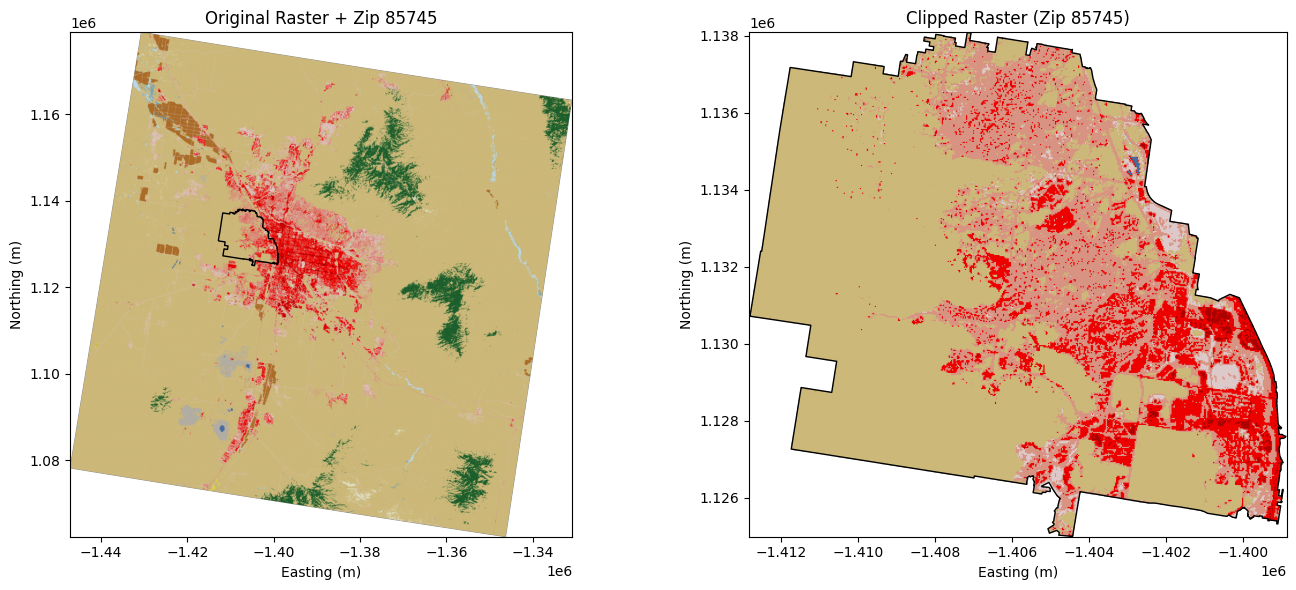

In [46]:
# --- Set the column name and value for the zip code you want ---
# Inspect zipcodes.columns above (Block 4) to find the right column name
zip_col   = 'ZIPCODE'      # update this to match your shapefile
zip_value = '85745'    # update this to the zip code you want

# Filter the GeoDataFrame to just that one zip code
single_zip = zipcodes_reproj[zipcodes_reproj[zip_col] == zip_value]

print(f'Number of features selected: {len(single_zip)}')

# Convert geometry to the format rasterio needs
single_zip_shape = [mapping(geom) for geom in single_zip.geometry]

# Clip the raster to that single polygon
with rasterio.open(lc_file) as src:
    lc_clipped_one, clip_transform_one = rio_mask(src, single_zip_shape, crop=True)

lc_clipped_one = lc_clipped_one[0]

print('Original landcover shape:       ', lc_data.shape)
print(f'Clipped to zip {zip_value} shape:', lc_clipped_one.shape)

# --- Plot pre- and post-clipped rasters (single zip) ---
nodata_plot = int(lc_nodata) if lc_nodata is not None else 0

orig_display = lc_data.astype(float)
orig_display[lc_data == nodata_plot] = np.nan

clip_display = lc_clipped_one.astype(float)
clip_display[lc_clipped_one == nodata_plot] = np.nan

# Build one shared NLCD colormap/norm so colors stay identical in both panels
all_classes = sorted(set(np.unique(lc_data)) - {nodata_plot})
shared_colors = [NLCD_CLASSES.get(int(c), ('Unknown', '#888888'))[1] for c in all_classes]
shared_cmap = ListedColormap(shared_colors)
shared_bounds = [c - 0.5 for c in all_classes] + [all_classes[-1] + 0.5]
shared_norm = BoundaryNorm(shared_bounds, shared_cmap.N)

# Extent for original raster
extent_orig = [lc_bounds.left, lc_bounds.right, lc_bounds.bottom, lc_bounds.top]

# Extent for clipped raster using the clip transform
rows_clip, cols_clip = lc_clipped_one.shape
left_clip   = clip_transform_one.c
top_clip    = clip_transform_one.f
right_clip  = left_clip + clip_transform_one.a * cols_clip
bottom_clip = top_clip + clip_transform_one.e * rows_clip
extent_clip = [left_clip, right_clip, bottom_clip, top_clip]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(orig_display, cmap=shared_cmap, norm=shared_norm, extent=extent_orig, origin='upper')
single_zip.boundary.plot(ax=axes[0], edgecolor='black', linewidth=1.0)
axes[0].set_title(f'Original Raster + Zip {zip_value}')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')

axes[1].imshow(clip_display, cmap=shared_cmap, norm=shared_norm, extent=extent_clip, origin='upper')
single_zip.boundary.plot(ax=axes[1], edgecolor='black', linewidth=1.0)
axes[1].set_title(f'Clipped Raster (Zip {zip_value})')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')

plt.tight_layout()
plt.show()

---
## 15. Summarize pixel counts by landcover type for every zip code

We loop over every row in the zip code GeoDataFrame, clip the raster to each polygon individually, and count the landcover pixels within it. The results are collected in a list of dictionaries and converted to a pandas DataFrame.

In [47]:
rows = []
skipped_no_overlap = 0
skipped_empty_geom = 0

for idx, zip_row in zipcodes_reproj.iterrows():

    zip_id = zip_row[zip_col]               # the zip code value for this polygon
    geom = zip_row.geometry

    if geom is None or geom.is_empty:
        skipped_empty_geom += 1
        continue

    zip_shape = [mapping(geom)]             # single geometry as a list

    # Clip the raster to this zip code polygon
    with rasterio.open(lc_file) as src:
        try:
            clipped, _ = rio_mask(src, zip_shape, crop=True, nodata=0)
        except ValueError:
            # Happens when shape does not overlap raster extent
            skipped_no_overlap += 1
            continue
    clipped = clipped[0]

    # Count pixels per NLCD class (skip nodata = 0)
    class_codes, class_counts = np.unique(clipped, return_counts=True)
    for code, count in zip(class_codes, class_counts):
        if code == 0:
            continue
        label = NLCD_CLASSES.get(int(code), ('Unknown', ''))[0]
        rows.append({'zip_code': zip_id, 'nlcd_code': int(code),
                     'label': label, 'pixels': int(count)})

# Combine all results into a single DataFrame
df_by_zip = pd.DataFrame(rows)

print('Summary of landcover pixels by zip code:')
print(df_by_zip.head(20).to_string(index=False))
print(f'\nTotal rows: {len(df_by_zip)}')
print(f'Skipped (no overlap): {skipped_no_overlap}')
print(f'Skipped (empty geometry): {skipped_empty_geom}')

Summary of landcover pixels by zip code:
zip_code  nlcd_code                     label  pixels
   85645         11                Open Water      12
   85645         21     Developed, Open Space    1783
   85645         22  Developed, Low Intensity    2550
   85645         23  Developed, Med Intensity     129
   85645         24 Developed, High Intensity       2
   85645         52               Shrub/Scrub  181789
   85645         71      Grassland/Herbaceous      16
   85645         81               Pasture/Hay     881
   85645         82          Cultivated Crops     152
   85645         90            Woody Wetlands      19
   85645         95   Emergent Herb. Wetlands      16
   85742         52               Shrub/Scrub   12843
   85742         71      Grassland/Herbaceous    1558
   85742         21     Developed, Open Space       1
   85742         22  Developed, Low Intensity       1
   85742         52               Shrub/Scrub     442
   85602         11                Open W

---
## 16. Summarize pixel counts by landcover type for the single clipped area

Using the clipped array we created in Block 14 (`lc_clipped_one`), we count how many pixels belong to each NLCD class and compute the percentage of the total area for that zip code.

In [48]:
# Count pixels per NLCD class in the clipped array from Block 14
class_codes, class_counts = np.unique(lc_clipped_one, return_counts=True)

# Build a summary DataFrame
rows = []
for code, count in zip(class_codes, class_counts):
    if code == 0:     # skip nodata
        continue
    label = NLCD_CLASSES.get(int(code), ('Unknown class', ''))[0]
    rows.append({'nlcd_code': int(code), 'label': label, 'pixels': int(count)})

df_one_zip = pd.DataFrame(rows)
df_one_zip['pct'] = 100 * df_one_zip['pixels'] / df_one_zip['pixels'].sum()
df_one_zip = df_one_zip.sort_values('pixels', ascending=False)

print(f'Landcover summary for zip code {zip_value}:')
print(f'{"Code":<6} {"Label":<30} {"Pixels":>12}  {"Pct":>6}')
print('-' * 58)
for _, r in df_one_zip.iterrows():
    print(f'{r.nlcd_code:<6} {r.label:<30} {r.pixels:>12,}  {r.pct:>5.1f}%')

Landcover summary for zip code 85745:
Code   Label                                Pixels     Pct
----------------------------------------------------------
52     Shrub/Scrub                          78,993   38.8%
250    Unknown class                        67,236   33.0%
22     Developed, Low Intensity             36,837   18.1%
23     Developed, Med Intensity             16,083    7.9%
21     Developed, Open Space                 3,283    1.6%
24     Developed, High Intensity             1,134    0.6%
11     Open Water                               60    0.0%
90     Woody Wetlands                           11    0.0%
81     Pasture/Hay                               5    0.0%
